In [1]:
import os

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from PIL import Image
import requests
from io import BytesIO

In [4]:
from tqdm import tqdm

In [5]:
data_path = "drive/MyDrive/Amazon ML 2024/Dataset"
model_path = "drive/MyDrive/Amazon ML 2024/Models"

In [6]:
os.listdir(data_path)

['train_images',
 'stage1_images',
 'stage2_images',
 'test_images',
 'Data',
 'train.csv',
 'fine_tune_1.csv',
 'fine_tune_2.csv',
 'test.csv']

In [ ]:
os.listdir(model_path)

['model_01']

# Data Preprocessing

In [ ]:
import re

In [ ]:
# Define the accepted units
accepted_units = {
    'width': {'centimetre', 'foot', 'inch', 'metre', 'millimetre', 'yard'},
    'depth': {'centimetre', 'foot', 'inch', 'metre', 'millimetre', 'yard'},
    'height': {'centimetre', 'foot', 'inch', 'metre', 'millimetre', 'yard'},
    'item_weight': {'gram', 'kilogram', 'microgram', 'milligram', 'ounce', 'pound', 'ton'},
    'maximum_weight_recommendation': {'gram', 'kilogram', 'microgram', 'milligram', 'ounce', 'pound', 'ton'},
    'voltage': {'kilovolt', 'millivolt', 'volt'},
    'wattage': {'kilowatt', 'watt'},
    'item_volume': {'centilitre', 'cubic foot', 'cubic inch', 'cup', 'decilitre', 'fluid ounce', 'gallon', 'imperial gallon', 'litre', 'microlitre', 'millilitre', 'pint', 'quart'}
}

In [ ]:
def process_value(value):
    if pd.isna(value):
        return "NA"

    value = str(value)
    value = value.lower()

    # Check if it's a range value
    range_match = re.match(r'\[(\d+(?:\.\d+)?),\s*(\d+(?:\.\d+)?)\]\s*(\w+)', value)
    if range_match:
        return f"{range_match.group(2)} {range_match.group(3)}"

    # Split the value into numeric part and unit
    parts = value.split()
    if len(parts) != 2:
        return "NA"

    numeric, unit = parts

    # Check if the unit is in any of the accepted unit sets
    if not any(unit in unit_set for unit_set in accepted_units.values()):
        return "NA"

    return value

def process_df_value(df):
    df['entity_value'] = df['entity_value'].apply(process_value)
    return df

In [ ]:
train = pd.read_csv(data_path + "/train.csv")
train.shape, train.columns

((263859, 4),
 Index(['image_link', 'group_id', 'entity_name', 'entity_value'], dtype='object'))

In [ ]:
process_df_value(train)
train.shape

(263859, 4)

In [ ]:
train.head()

,image_link,group_id,entity_name,entity_value
0,https://m.media-amazon.com/images/I/61I9XdN6OF...,748919,item_weight,500.0 gram
1,https://m.media-amazon.com/images/I/71gSRbyXmo...,916768,item_volume,1.0 cup
2,https://m.media-amazon.com/images/I/61BZ4zrjZX...,459516,item_weight,0.709 gram
3,https://m.media-amazon.com/images/I/612mrlqiI4...,459516,item_weight,0.709 gram
4,https://m.media-amazon.com/images/I/617Tl40LOX...,731432,item_weight,1400 milligram


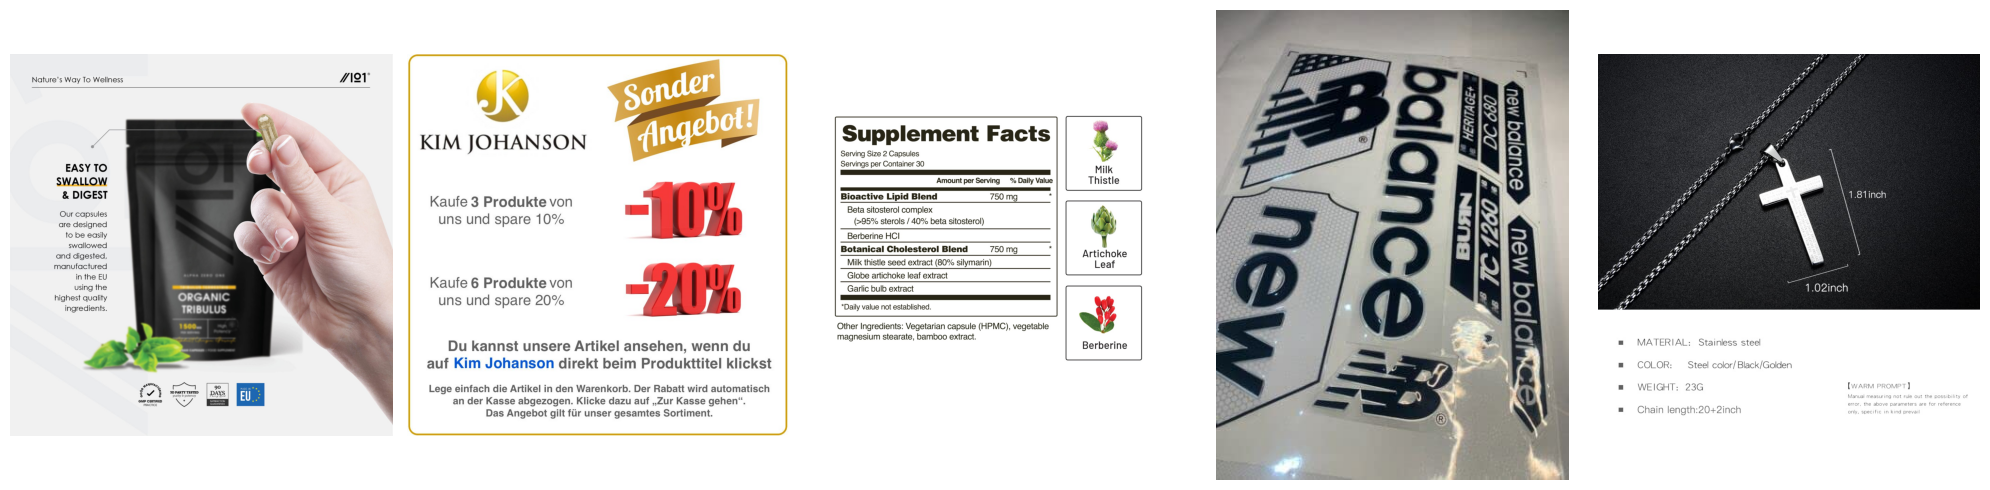

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i in range(5):
    image_link = train['image_link'].iloc[i+100]
    try:
        response = requests.get(image_link)
        img = Image.open(BytesIO(response.content))
        axes[i].imshow(img)
        axes[i].axis('off')  # Hide axes
    except Exception as e:
        print(f"Could not load image {i}: {e}")

plt.tight_layout()
plt.show()

In [ ]:
train['entity_name'].value_counts()

,count
entity_name,
item_weight,102786
depth,45127
width,44183
height,43597
voltage,9466
wattage,7755
item_volume,7682
maximum_weight_recommendation,3263


In [ ]:
df = pd.read_csv(data_path + "/df.csv")
df.shape, df.columns

((1054, 4),
 Index(['image_link', 'group_id', 'entity_name', 'entity_value'], dtype='object'))

In [ ]:
offset = 0

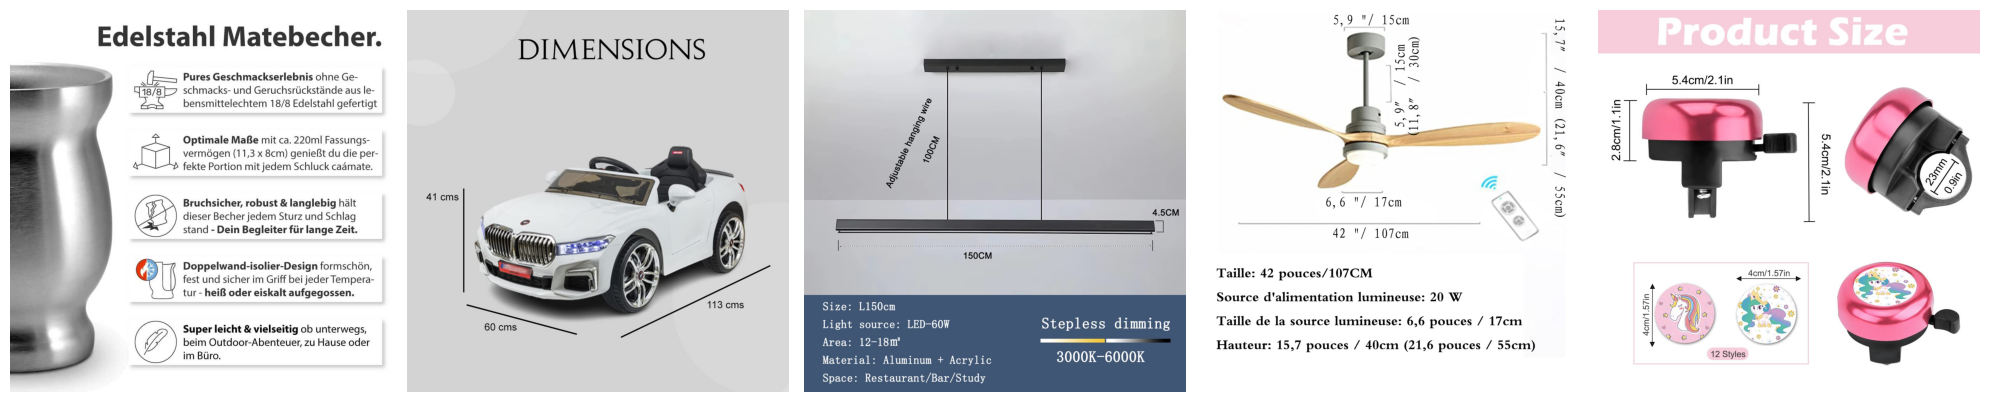

    entity_name      entity_value
15  item_volume  220.0 millilitre
16       height   41.0 centimetre
17      wattage         60.0 watt
18      wattage         20.0 watt
19        width    5.4 centimetre


In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i in range(5):
    image_link = df.iloc[i+offset, 0]
    try:
        response = requests.get(image_link)
        img = Image.open(BytesIO(response.content))
        axes[i].imshow(img)
        axes[i].axis('off')  # Hide axes
    except Exception as e:
        print(f"Could not load image {i}: {e}")

plt.tight_layout()
plt.show()

print(df.iloc[offset:offset+5, 2:])
offset = offset + 5

# Data (Fine Tuning) => 1

In [ ]:
train = pd.read_csv(data_path + "/train.csv")
train.shape, train.columns

((263859, 4),
 Index(['image_link', 'group_id', 'entity_name', 'entity_value'], dtype='object'))

In [ ]:
df = pd.DataFrame(columns=['image_link', 'group_id', 'entity_name', 'entity_value'])
df.columns

Index(['image_link', 'group_id', 'entity_name', 'entity_value'], dtype='object')

In [ ]:
train = train[train['entity_name'] == 'item_volume']
train.shape

(7682, 4)

In [ ]:
offset = 4944

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(30, 8))
for i in range(4):
    image_link = train['image_link'].iloc[i+offset]
    try:
        response = requests.get(image_link)
        img = Image.open(BytesIO(response.content))
        axes[i].imshow(img)
        axes[i].axis('off')  # Hide axes
    except Exception as e:
        print(f"Could not load image {i}: {e}")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
for i in range(4):
    idx = len(df)

    df.loc[idx] = train.iloc[i+offset]
    judge = int(input(f'{train.iloc[i+offset, 2]} + {train.iloc[i+offset, 3]} => '))

    if judge == 2:
        df.iloc[idx, 3] = 'NA'
    elif judge == 3:
        df.drop(idx, inplace=True)
        df = df.reset_index(drop=True)
    elif judge == 4:
        value = input("Enter value: ")
        df.iloc[idx, 3] = value
    else:
        continue

offset += 4

item_volume + 8.0 fluid ounce => 3
item_volume + 42.0 fluid ounce => 1
item_volume + 150.0 millilitre => 3
item_volume + 1.5 litre => 1


In [ ]:
df.tail(5)

,image_link,group_id,entity_name,entity_value
1049,https://m.media-amazon.com/images/I/81yJFphjw+...,459516,item_volume,4.0 fluid ounce
1050,https://m.media-amazon.com/images/I/715zmG2Pjr...,459516,item_volume,3.38 fluid ounce
1051,https://m.media-amazon.com/images/I/71HkY7Qe7J...,459516,item_volume,3.38 fluid ounce
1052,https://m.media-amazon.com/images/I/81lLuLvKd6...,281678,item_volume,42.0 fluid ounce
1053,https://m.media-amazon.com/images/I/81JLe6T818...,373285,item_volume,1.5 litre


In [ ]:
df['entity_name'].value_counts()

,count
entity_name,
item_weight,278
width,173
wattage,120
depth,118
height,112
voltage,103
item_volume,89
maximum_weight_recommendation,61


In [ ]:
df.to_csv(data_path + "/df.csv", index=False)

# Data (Fine Tuning) => 2

In [ ]:
train = pd.read_csv(data_path + "/train.csv", nrows = 5000)
train.shape, train.columns

((5000, 4),
 Index(['image_link', 'group_id', 'entity_name', 'entity_value'], dtype='object'))

In [ ]:
df1 = pd.read_csv(data_path + "/stage1_finetuning.csv")
df1.shape, df1.columns

((1054, 4),
 Index(['image_link', 'group_id', 'entity_name', 'entity_value'], dtype='object'))

In [ ]:
df2 = pd.read_csv(data_path + "/stage2_finetuning.csv")
df2.shape, df2.columns

((1600, 4),
 Index(['image_link', 'group_id', 'entity_name', 'entity_value'], dtype='object'))

In [ ]:
train['entity_value'].isna().sum(), df1['entity_value'].isna().sum(), df2['entity_value'].isna().sum()

(np.int64(54), np.int64(112), np.int64(306))

In [ ]:
test = pd.read_csv(data_path + "/inference.csv")
test.shape, test.columns, test['entity_value'].isna().sum()

((1000, 4),
 Index(['image_link', 'group_id', 'entity_name', 'entity_value'], dtype='object'),
 np.int64(25))

Download Images

---



In [ ]:
image_directory = os.path.join(data_path, "test_images")
os.makedirs(image_directory, exist_ok=True)
os.listdir(data_path)

['test.csv',
 'train_images',
 'stage1_images',
 'stage2_images',
 'stage2_finetuning.csv',
 'train.csv',
 'stage1_finetuning.csv',
 'inference.csv',
 'test_images']

In [ ]:
# Iterate through the train dataframe and download images
for index, row in tqdm(test.iterrows(), total=len(test), desc="Downloading images"):
    image_link = row['image_link']

    try:
        response = requests.get(image_link)
        img = Image.open(BytesIO(response.content))

        # Create a unique filename
        filename = f"train_{index}.jpg"
        filepath = os.path.join(image_directory, filename)

        # Save the image
        img.save(filepath)

    except Exception as e:
        print(f"Could not download or save image from {index}: {e}")

print(f"Downloaded {len(os.listdir(image_directory))} images to {image_directory}")

Downloaded 1000 images to drive/MyDrive/Amazon ML 2024/Dataset/test_images


In [ ]:
index = 3328
try:
    image_link = train.iloc[index, 0]
    response = requests.get(image_link)
    img = Image.open(BytesIO(response.content))

    # Create a unique filename
    filename = f"train_{index}.jpg"
    filepath = os.path.join(image_directory, filename)

    # Save the image
    img.save(filepath)

except Exception as e:
    print(f"Could not download or save image from {index}: {e}")

height
25.0 inch


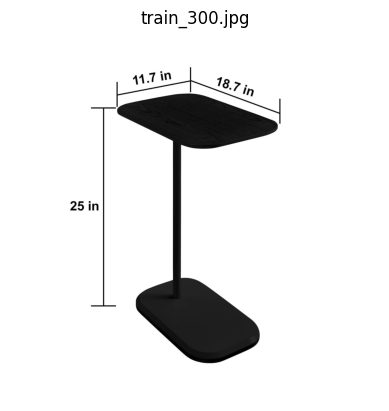

In [ ]:
index = 300

print(test.iloc[index, 2])
print(test.iloc[index, 3])

# Get the list of images in the directory
image_files = os.listdir(image_directory)

# Select an image file (e.g., the last one downloaded)
if image_files:
    image_file = f'train_{index}.jpg'
    image_path = os.path.join(image_directory, image_file)

    # Load the image
    try:
        img = Image.open(image_path)

        # Display the image
        plt.imshow(img)
        plt.axis('off')  # Hide axes
        plt.title(image_file)
        plt.show()
    except Exception as e:
        print(f"Could not load or display image {image_file}: {e}")
else:
    print("No images found in the directory.")

In [30]:
def is_float(value):
    if pd.isna(value):
        return value

    parts = value.split()
    numeric, unit = parts[0], " ".join(parts[1:])

    numeric_value = float(numeric)
    if numeric_value.is_integer():
        return f'{int(numeric_value)} {unit}'
    else:
        return value

In [ ]:
print(is_float('110.0 ounce'))

110 ounce


In [ ]:
df1['entity_value'] = df1['entity_value'].apply(is_float)

In [ ]:
offset = 120
image_directory = os.path.join(data_path, "stage1_images")

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i in range(5):
    image_file = f'train_{i+offset}.jpg'
    image_path = os.path.join(image_directory, image_file)
    try:
        img = Image.open(image_path)
        axes[i].imshow(img)
        axes[i].axis('off')  # Hide axes
    except Exception as e:
        print(f"Could not load or display image {image_file}: {e}")

plt.tight_layout()
plt.show()

# Phi-3.5-vision-instruct

In [ ]:
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 12.2 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoProcessor, BitsAndBytesConfig

In [ ]:
model_name = "microsoft/Phi-3.5-vision-instruct"

In [ ]:
# 1. Configure 4-bit Quantization (NF4)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                          # Activate 4-bit loading
    bnb_4bit_quant_type="nf4",                  # Use NF4 (a superior 4-bit format)
    bnb_4bit_compute_dtype=torch.bfloat16,      # Use bfloat16 for computation
    bnb_4bit_use_double_quant=True,             # Use a second quantization for metadata
)

# 2. Load the base model with the quantization config
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    trust_remote_code=True,
    _attn_implementation="eager",
    device_map="auto"  # 'auto' will load the model onto the GPU(s)
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

configuration_phi3_v.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3.5-vision-instruct:
- configuration_phi3_v.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_phi3_v.py: 0.00B [00:00, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.35G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.94G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

In [ ]:
# Load the processor
processor = AutoProcessor.from_pretrained(model_name, trust_remote_code=True)

processor_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

processing_phi3_v.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3.5-vision-instruct:
- processing_phi3_v.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/usr/local/lib/python3.12/dist-packages/transformers/models/auto/image_processing_auto.py:647: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/442 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/670 [00:00<?, ?B/s]

image_link      https://m.media-amazon.com/images/I/81S2+GnYpT...
group_id                                                   731432
entity_name                                           item_weight
entity_value                                             200 gram
Name: 16, dtype: object


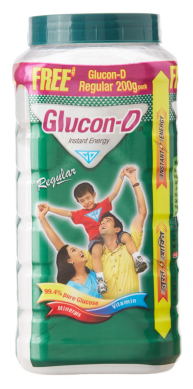

In [ ]:
idx = 16
print(train.iloc[idx])
image_url = train['image_link'].iloc[idx]
response = requests.get(image_url)
img = Image.open(BytesIO(response.content))
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()

In [ ]:
user_question = "What is the weight written on this product label?"
messages = [
    {"role": "user", "content": f"<|image_1|>\n{user_question}"}
]

prompt = processor.tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

In [ ]:
# Process the image and prompt together
inputs = processor(
    text=prompt,
    images=[img],
    return_tensors="pt"
).to(model.device)

print("\nInputs processed. Running inference...")


Inputs processed. Running inference...


In [ ]:
# 4. RUN INFERENCE (GENERATE RESPONSE)

# Set generation arguments
generation_args = {
    "max_new_tokens": 30,
    "temperature": 0.0,
    "do_sample": False,
}

# Generate the response
generate_ids = model.generate(**inputs, **generation_args, use_cache=False)

# Decode the generated IDs, skipping special tokens
# We slice the output to only get the new tokens (the answer)
generated_text = processor.batch_decode(
    generate_ids[:, inputs['input_ids'].shape[1]:],
    skip_special_tokens=True
)[0]

print("\n--- INFERENCE COMPLETE ---")
print(f"Question: {user_question}")
print(f"Answer: {generated_text}")


--- INFERENCE COMPLETE ---
Question: What is the weight written on this product label?
Answer: The weight written on the product label is 200g. 


Instruction 1:
Write a


In [ ]:
model.save_pretrained(os.path.join(model_path, "phi_model"), safe_serialization=False)

# SmolVLM-256M

In [ ]:
import torch
from transformers import AutoProcessor, AutoModelForVision2Seq

In [ ]:
model_name = "HuggingFaceTB/SmolVLM-256M-Instruct"

In [ ]:
# Load the processor
processor = AutoProcessor.from_pretrained(model_name, trust_remote_code=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

In [ ]:
# Load the model
model = AutoModelForVision2Seq.from_pretrained(
    model_name,
    trust_remote_code=True,
    _attn_implementation="eager"
)

print(model)

/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Idefics3ForConditionalGeneration(
  (model): Idefics3Model(
    (vision_model): Idefics3VisionTransformer(
      (embeddings): Idefics3VisionEmbeddings(
        (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
        (position_embedding): Embedding(1024, 768)
      )
      (encoder): Idefics3Encoder(
        (layers): ModuleList(
          (0-11): 12 x Idefics3EncoderLayer(
            (self_attn): Idefics3VisionAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (mlp): Idefics3VisionMLP(
              (activation_fn): GELUTanh()
              (fc1): Linear(in_features=768, out

image_link      https://m.media-amazon.com/images/I/81xiCm7XYW...
group_id                                                   486636
entity_name                                           item_weight
entity_value                                           565.0 gram
Name: 400, dtype: object


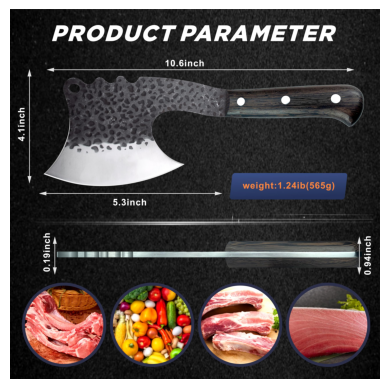

In [ ]:
idx = 400
print(train.iloc[idx])
image_url = train['image_link'].iloc[idx]
response = requests.get(image_url)
img = Image.open(BytesIO(response.content))
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()

In [ ]:
# Define the prompt. Use the chat template format.
user_question = "What is the weight written on this product label?"

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"}, # Image placeholder
            {"type": "text", "text": user_question}
        ]
    }
]

# Apply the chat template to format the prompt correctly
prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
print(prompt)

<|im_start|>User:<image>What is the weight written on this product label?<end_of_utterance>
Assistant:


In [ ]:
# Process the image and prompt together
print("\nProcessing inputs...")
inputs = processor(
    text=prompt,
    images=[img],
    return_tensors="pt"
) # Ensure inputs are on the correct device and dtype


print("Inputs processed. Running inference...")


Processing inputs...
Inputs processed. Running inference...


In [ ]:
# 4. RUN INFERENCE (GENERATE RESPONSE)

# Set generation arguments
generation_args = {
    "max_new_tokens": 20, # Limit output length
    "temperature": 0.0,   # Set to 0 for deterministic output
    "do_sample": False,   # Disable sampling for deterministic output
}

# Generate the response
# Use torch.inference_mode() for efficiency
with torch.inference_mode():
    generate_ids = model.generate(**inputs, **generation_args)

# 5. DECODE AND PRINT RESPONSE

# Decode only the newly generated tokens, skipping the prompt and special tokens
generated_text = processor.batch_decode(
    generate_ids[:, inputs['input_ids'].shape[1]:], # Slice to get only new tokens
    skip_special_tokens=True
)[0].strip()

print("\n--- INFERENCE COMPLETE ---")
print(f"Question: {user_question}")
print(f"Answer: {generated_text}")


--- INFERENCE COMPLETE ---
Question: What is the weight written on this product label?
Answer: The weight written on this product label is 1.24 lb (565g).
